<a href="https://colab.research.google.com/github/fatimashahzad2223/supply-chain-analytics-portfolio-fall-2026-IBA/blob/main/01-forecasting/forecasting-analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [9]:
print("setup working:",pd.__version__)


setup working: 2.2.3


In [15]:
import pandas as pd
df = pd.read_excel("Chenab_Motors_Procurement_Practice_Dataset.xlsx",sheet_name="Procurement_Data")
print(df.shape)
print(df.head())


(10050, 22)
   PO Number  PO Line Item Vendor ID                  Vendor  \
0  PO-100307             2    V-1057  Al-Noor Fabric Exports   
1  PO-101660             1    V-1010    Modern Fasteners Co.   
2  PO-107059             1    V-1055   Wazir Ali Enterprises   
3  PO-102998             1    V-1027      Eco Weave Pakistan   
4  PO-106461             1    V-1032   Al-Rehan Fabric Mills   

              Plant         Department Cost Center Requisitioner  \
0      Lahore Plant  Quality Assurance     CC-3001   I. Chaudhry   
1  Faisalabad Plant         Production     CC-1003      H. Malik   
2  Faisalabad Plant                 IT     CC-5001   I. Chaudhry   
3     Karachi Plant        Maintenance     CC-2001     N. Sheikh   
4      Lahore Plant     Administration     CC-6002      Z. Latif   

                   Material Group  Quantity  ...        Creation Date  \
0                    MRO & Spares         3  ...  2024-05-31 00:00:00   
1  Engine & Powertrain Components        11  ...

In [24]:
# Replace 'your_excel_file.xlsx' with the actual name of your Excel file
file_path = '/content/Chenab_Motors_Procurement_Practice_Dataset.xlsx'

try:
    # Load the specific sheet that contains the procurement data
    df = pd.read_excel(file_path, sheet_name="Procurement_Data")
    print(f"Successfully loaded '{file_path}' (sheet: Procurement_Data) with {len(df)} rows and {len(df.columns)} columns.")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please check the file path and ensure it's uploaded.")
except KeyError:
    print(f"Error: Sheet 'Procurement_Data' not found in '{file_path}'. Please check sheet name.")
except Exception as e:
    print(f"An error occurred while loading the file: {e}")

Successfully loaded '/content/Chenab_Motors_Procurement_Practice_Dataset.xlsx' (sheet: Procurement_Data) with 10050 rows and 22 columns.


,PO Number,PO Line Item,Vendor ID,Vendor,Plant,Department,Cost Center,Requisitioner,Material Group,Quantity,...,Creation Date,GR Date,GR Value (PKR),Invoice Date,Invoice Amount (PKR),Paid Amount (PKR),Outstanding Invoice (PKR),Payment Terms,Currency,PO Status
0,PO-100307,2,V-1057,Al-Noor Fabric Exports,Lahore Plant,Quality Assurance,CC-3001,I. Chaudhry,MRO & Spares,3,...,2024-05-31 00:00:00,2024-06-17,7293.0,2024-06-18,7185.0,2910,4275,Net 60,PKR,Partially Invoiced
1,PO-101660,1,V-1010,Modern Fasteners Co.,Faisalabad Plant,Production,CC-1003,H. Malik,Engine & Powertrain Components,11,...,2024-07-23 00:00:00,2024-07-30,256257.0,2024-08-09,256526.0,63790,192736,Net 45,PKR,Partially Invoiced
2,PO-107059,1,V-1055,Wazir Ali Enterprises,Faisalabad Plant,IT,CC-5001,I. Chaudhry,Interior Components,3,...,2025-05-11 00:00:00,2025-05-16,9539.0,2025-05-23,9586.0,9586,0,Net 30,PKR,Closed
3,PO-102998,1,V-1027,Eco Weave Pakistan,Karachi Plant,Maintenance,CC-2001,N. Sheikh,Body Panels & Sheet Metal,7,...,2024-10-09 00:00:00,2024-10-23,115883.0,2024-10-27,116924.0,116924,0,Net 45,PKR,Closed
4,PO-106461,1,V-1032,Al-Rehan Fabric Mills,Lahore Plant,Administration,CC-6002,Z. Latif,Office Supplies & Stationery,1,...,2025-03-03 00:00:00,2025-03-07,523.0,2025-03-15,517.0,517,0,Net 30,PKR,Closed


In [29]:
# Display basic information about the DataFrame to understand its structure and data types
print("\nDataFrame Info:")
df.info()

# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# Rename columns for consistency with the analysis logic
# We've identified 'Vendor' as the supplier name and 'PO Value (PKR)' as the total spend.
if 'Vendor' in df.columns and 'PO Value (PKR)' in df.columns:
    df.rename(columns={'Vendor': 'Supplier Name', 'PO Value (PKR)': 'Total_Spend'}, inplace=True)
    print("\nColumns 'Vendor' and 'PO Value (PKR)' renamed to 'Supplier Name' and 'Total_Spend'.")

    # Convert 'Total_Spend' to numeric, coercing errors to NaN
    df['Total_Spend'] = pd.to_numeric(df['Total_Spend'], errors='coerce')

    # Drop rows where 'Total_Spend' is missing after conversion, as these can't be used for spend analysis
    df.dropna(subset=['Total_Spend'], inplace=True)

    # Ensure 'Supplier Name' column is clean (e.g., fill NaNs if any)
    df['Supplier Name'].fillna('Unknown Supplier', inplace=True)

else:
    print("Error: Expected columns 'Vendor' and 'PO Value (PKR)' not found. Please check column names in your Excel file.")

# Display cleaned data info
print("\nDataFrame Info after cleaning:")
df.info()
display(df.head())


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10050 entries, 0 to 10049
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   PO Number                  10050 non-null  object        
 1   PO Line Item               10050 non-null  int64         
 2   Vendor ID                  10050 non-null  object        
 3   Supplier Name              10050 non-null  object        
 4   Plant                      10050 non-null  object        
 5   Department                 10050 non-null  object        
 6   Cost Center                9929 non-null   object        
 7   Requisitioner              10050 non-null  object        
 8   Material Group             9927 non-null   object        
 9   Quantity                   10050 non-null  int64         
 10  Unit Price (PKR)           10050 non-null  int64         
 11  Total_Spend                10050 non-null  float64

,PO Number,PO Line Item,Vendor ID,Supplier Name,Plant,Department,Cost Center,Requisitioner,Material Group,Quantity,...,Creation Date,GR Date,GR Value (PKR),Invoice Date,Invoice Amount (PKR),Paid Amount (PKR),Outstanding Invoice (PKR),Payment Terms,Currency,PO Status
0,PO-100307,2,V-1057,Al-Noor Fabric Exports,Lahore Plant,Quality Assurance,CC-3001,I. Chaudhry,MRO & Spares,3,...,2024-05-31 00:00:00,2024-06-17,7293.0,2024-06-18,7185.0,2910,4275,Net 60,PKR,Partially Invoiced
1,PO-101660,1,V-1010,Modern Fasteners Co.,Faisalabad Plant,Production,CC-1003,H. Malik,Engine & Powertrain Components,11,...,2024-07-23 00:00:00,2024-07-30,256257.0,2024-08-09,256526.0,63790,192736,Net 45,PKR,Partially Invoiced
2,PO-107059,1,V-1055,Wazir Ali Enterprises,Faisalabad Plant,IT,CC-5001,I. Chaudhry,Interior Components,3,...,2025-05-11 00:00:00,2025-05-16,9539.0,2025-05-23,9586.0,9586,0,Net 30,PKR,Closed
3,PO-102998,1,V-1027,Eco Weave Pakistan,Karachi Plant,Maintenance,CC-2001,N. Sheikh,Body Panels & Sheet Metal,7,...,2024-10-09 00:00:00,2024-10-23,115883.0,2024-10-27,116924.0,116924,0,Net 45,PKR,Closed
4,PO-106461,1,V-1032,Al-Rehan Fabric Mills,Lahore Plant,Administration,CC-6002,Z. Latif,Office Supplies & Stationery,1,...,2025-03-03 00:00:00,2025-03-07,523.0,2025-03-15,517.0,517,0,Net 30,PKR,Closed


In [30]:
if 'Supplier Name' in df.columns and 'Total_Spend' in df.columns:
    # Group by 'Supplier Name' and sum 'Total_Spend'
    supplier_spend = df.groupby('Supplier Name')['Total_Spend'].sum().reset_index()

    # Sort in descending order to find top 10 suppliers
    top_suppliers = supplier_spend.sort_values(by='Total_Spend', ascending=False).head(10)

    print("\nTop 10 Suppliers by Total Spend (PO Value):")
    display(top_suppliers)
else:
    print("Cannot calculate top suppliers. Ensure 'Supplier Name' and 'Total_Spend' columns are available and correctly named.")


Top 10 Suppliers by Total Spend (PO Value):


,Supplier Name,Total_Spend
0,Al-Amin Auto Components,1.018835e+08
27,Karachi Steel Traders,5.007253e+07
60,Zaman Brothers Trading,3.586614e+07
5,Anwar Electric Works,3.146678e+07
54,TCS Cargo Services,2.703754e+07
21,Gulistan Logistics,1.972002e+07
51,Speedline Logistics,1.750654e+07
49,Sindh Spinners Co.,1.655498e+07
56,United Rubber Industries,1.587658e+07
31,Modern Fasteners Co.,1.338250e+07


/tmp/ipykernel_535/2577515720.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Total_Spend', y='Supplier Name', data=top_suppliers, palette='viridis')


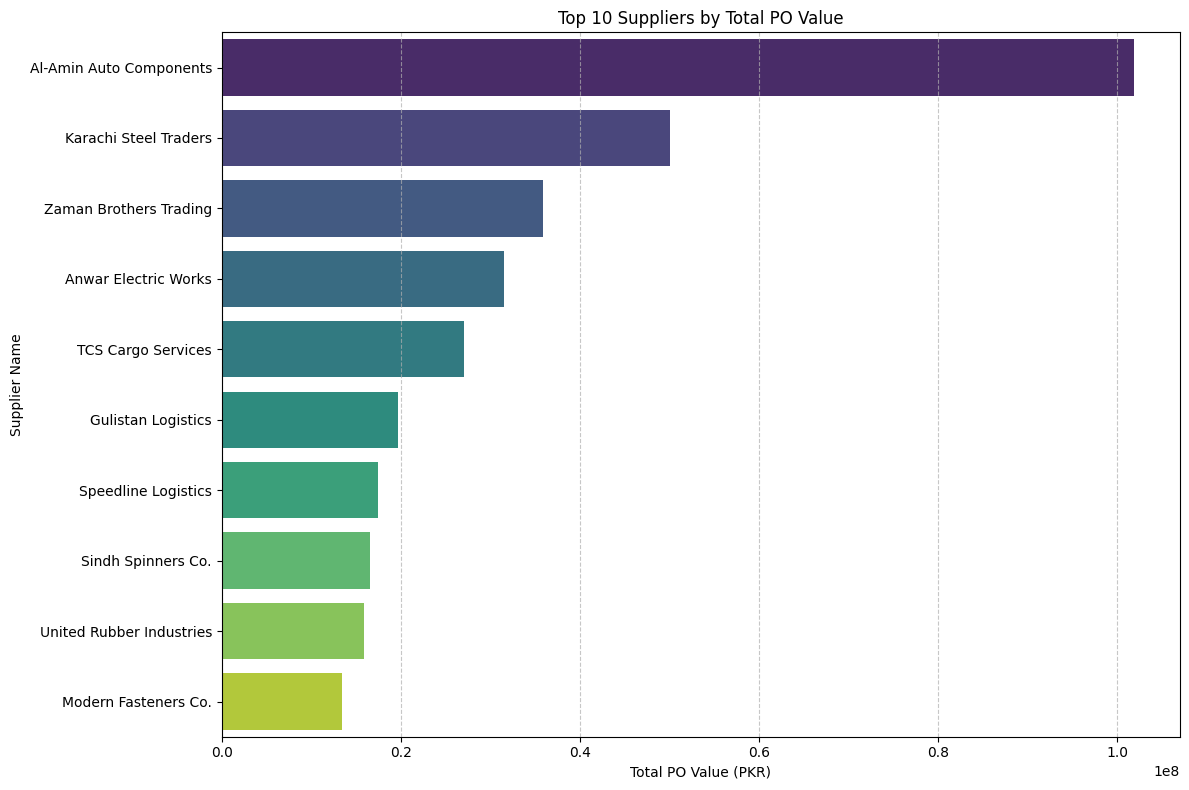

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'Supplier Name' in df.columns and 'Total_Spend' in df.columns:
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Total_Spend', y='Supplier Name', data=top_suppliers, palette='viridis')
    plt.title('Top 10 Suppliers by Total PO Value')
    plt.xlabel('Total PO Value (PKR)')
    plt.ylabel('Supplier Name')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("Cannot visualize top suppliers. Ensure 'Supplier Name' and 'Total_Spend' columns are available.")

In [32]:
if 'Supplier Name' in df.columns and 'Total_Spend' in df.columns:
    display(top_suppliers.style.format({
        'Total_Spend': "PKR {:,.2f}"  # Format Total_Spend as currency
    }).set_caption("Summary of Top 10 Suppliers by Total PO Value"))
else:
    print("Summary table cannot be generated. Check column availability.")

,Supplier Name,Total_Spend
0,Al-Amin Auto Components,"PKR 101,883,508.48"
27,Karachi Steel Traders,"PKR 50,072,526.35"
60,Zaman Brothers Trading,"PKR 35,866,143.00"
5,Anwar Electric Works,"PKR 31,466,779.06"
54,TCS Cargo Services,"PKR 27,037,544.59"
21,Gulistan Logistics,"PKR 19,720,020.00"
51,Speedline Logistics,"PKR 17,506,543.00"
49,Sindh Spinners Co.,"PKR 16,554,979.29"
56,United Rubber Industries,"PKR 15,876,581.00"
31,Modern Fasteners Co.,"PKR 13,382,503.00"


## Key Procurement Metrics

Let's calculate some key procurement metrics to get a high-level overview of the data.

In [35]:
# 1. Total PO Spend
total_po_spend = df['Total_Spend'].sum()

# 2. Total Number of POs (unique PO Numbers)
total_pos = df['PO Number'].nunique()

# 3. Total Number of Vendors (unique Supplier Names)
total_vendors = df['Supplier Name'].nunique()

# 4. Average PO Value (Total PO Spend / Total unique POs)
# To calculate average PO value, we should first group by PO Number and sum their Total_Spend
po_total_spend = df.groupby('PO Number')['Total_Spend'].sum()
average_po_value = po_total_spend.mean()

# 5. Average Line-Item Value (Total PO Spend / Total number of line items)
# Assuming each row represents a unique line item
total_line_items = len(df)
average_line_item_value = total_po_spend / total_line_items

# Display the results
print(f"\n--- Procurement Key Metrics ---")
print(f"Total PO Spend: PKR {total_po_spend:,.2f}")
print(f"Total Number of POs: {total_pos:,}")
print(f"Total Number of Vendors: {total_vendors:,}")
print(f"Average PO Value: PKR {average_po_value:,.2f}")
print(f"Average Line-Item Value: PKR {average_line_item_value:,.2f}")
print(f"------------------------------")


--- Procurement Key Metrics ---
Total PO Spend: PKR 614,670,044.11
Total Number of POs: 7,406
Total Number of Vendors: 61
Average PO Value: PKR 82,996.23
Average Line-Item Value: PKR 61,161.20
------------------------------


## Pareto Analysis of Vendors by PO Value (Total Spend)

The Pareto principle, also known as the 80/20 rule, states that roughly 80% of effects come from 20% of causes. In procurement, this often means that a small percentage of vendors account for a large percentage of total spend. Let's apply this analysis to identify our most significant vendors.

In [36]:
# Ensure 'supplier_spend' is sorted in descending order of 'Total_Spend'
pareto_df = supplier_spend.sort_values(by='Total_Spend', ascending=False).reset_index(drop=True)

# Calculate Cumulative Sum of Total_Spend
pareto_df['Cumulative_Spend'] = pareto_df['Total_Spend'].cumsum()

# Calculate Cumulative Percentage of Total_Spend
total_overall_spend = pareto_df['Total_Spend'].sum()
pareto_df['Cumulative_Spend_Percentage'] = (pareto_df['Cumulative_Spend'] / total_overall_spend) * 100

# Display the Pareto analysis table
print("\nPareto Analysis of Vendors:")
display(pareto_df.head(15).style.format({
    'Total_Spend': "PKR {:,.2f}",
    'Cumulative_Spend': "PKR {:,.2f}",
    'Cumulative_Spend_Percentage': "{:,.2f}%"
}))

# Identify vendors contributing to ~80% of total spend
pareto_80_percent_vendors = pareto_df[pareto_df['Cumulative_Spend_Percentage'] <= 80]
num_80_percent_vendors = len(pareto_80_percent_vendors)
percentage_of_vendors = (num_80_percent_vendors / len(pareto_df)) * 100

print(f"\nApproximately {num_80_percent_vendors} vendors ({percentage_of_vendors:,.2f}% of total vendors) account for 80% of the total spend.")
print("Vendors contributing to approximately 80% of total spend:")
display(pareto_80_percent_vendors.style.format({
    'Total_Spend': "PKR {:,.2f}",
    'Cumulative_Spend': "PKR {:,.2f}",
    'Cumulative_Spend_Percentage': "{:,.2f}%"
}))


Pareto Analysis of Vendors:


,Supplier Name,Total_Spend,Cumulative_Spend,Cumulative_Spend_Percentage
0,Al-Amin Auto Components,"PKR 101,883,508.48","PKR 101,883,508.48",16.58%
1,Karachi Steel Traders,"PKR 50,072,526.35","PKR 151,956,034.82",24.72%
2,Zaman Brothers Trading,"PKR 35,866,143.00","PKR 187,822,177.82",30.56%
3,Anwar Electric Works,"PKR 31,466,779.06","PKR 219,288,956.89",35.68%
4,TCS Cargo Services,"PKR 27,037,544.59","PKR 246,326,501.47",40.07%
5,Gulistan Logistics,"PKR 19,720,020.00","PKR 266,046,521.47",43.28%
6,Speedline Logistics,"PKR 17,506,543.00","PKR 283,553,064.47",46.13%
7,Sindh Spinners Co.,"PKR 16,554,979.29","PKR 300,108,043.76",48.82%
8,United Rubber Industries,"PKR 15,876,581.00","PKR 315,984,624.76",51.41%
9,Modern Fasteners Co.,"PKR 13,382,503.00","PKR 329,367,127.76",53.58%



Approximately 28 vendors (45.90% of total vendors) account for 80% of the total spend.
Vendors contributing to approximately 80% of total spend:


,Supplier Name,Total_Spend,Cumulative_Spend,Cumulative_Spend_Percentage
0,Al-Amin Auto Components,"PKR 101,883,508.48","PKR 101,883,508.48",16.58%
1,Karachi Steel Traders,"PKR 50,072,526.35","PKR 151,956,034.82",24.72%
2,Zaman Brothers Trading,"PKR 35,866,143.00","PKR 187,822,177.82",30.56%
3,Anwar Electric Works,"PKR 31,466,779.06","PKR 219,288,956.89",35.68%
4,TCS Cargo Services,"PKR 27,037,544.59","PKR 246,326,501.47",40.07%
5,Gulistan Logistics,"PKR 19,720,020.00","PKR 266,046,521.47",43.28%
6,Speedline Logistics,"PKR 17,506,543.00","PKR 283,553,064.47",46.13%
7,Sindh Spinners Co.,"PKR 16,554,979.29","PKR 300,108,043.76",48.82%
8,United Rubber Industries,"PKR 15,876,581.00","PKR 315,984,624.76",51.41%
9,Modern Fasteners Co.,"PKR 13,382,503.00","PKR 329,367,127.76",53.58%


## Visualization of Pareto Analysis

This chart visually represents the individual spend of each vendor and the cumulative spend percentage, making it easy to identify the 80% threshold.

/tmp/ipykernel_535/1598223239.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pareto_df.index, y='Total_Spend', data=pareto_df, palette='viridis', ax=ax1)


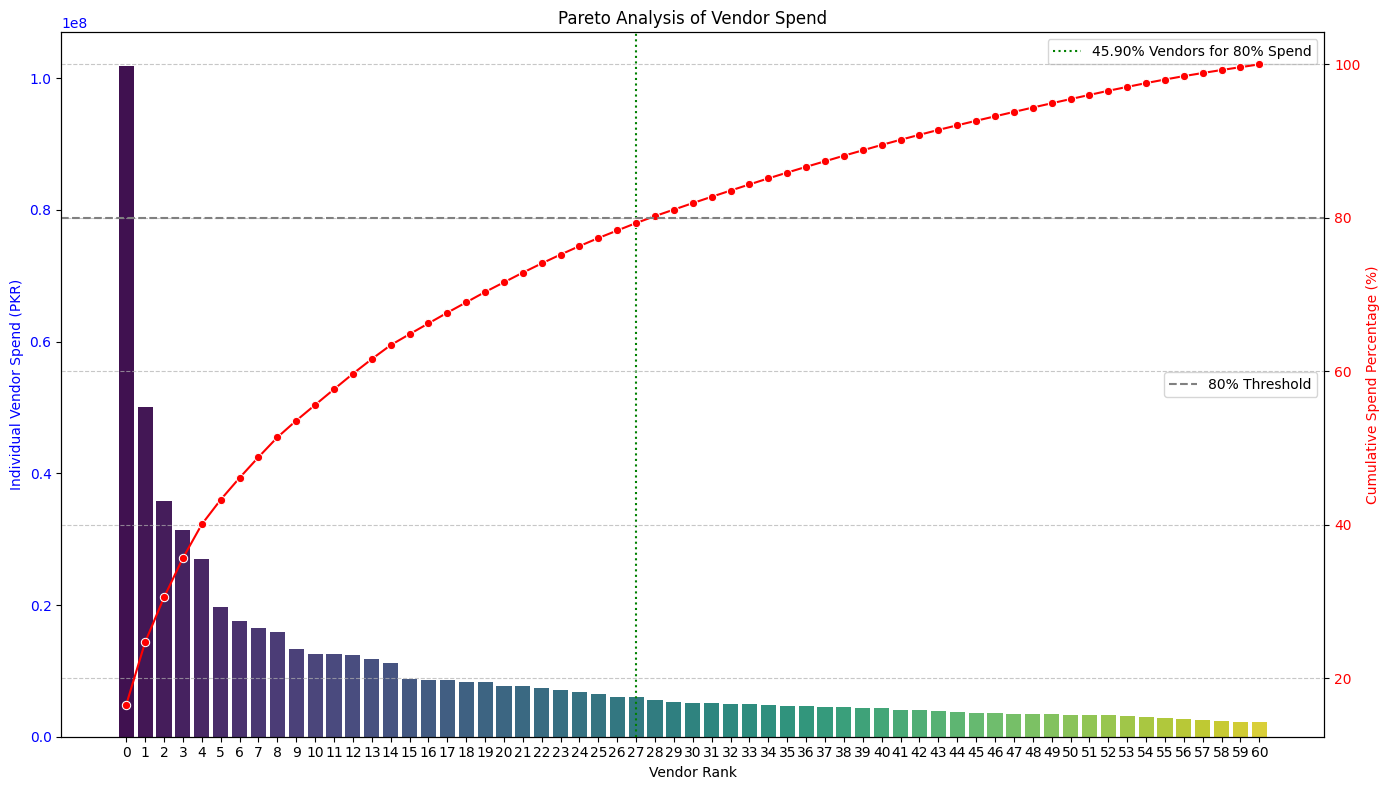

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax1 = plt.subplots(figsize=(14, 8))

# Bar plot for individual vendor spend
sns.barplot(x=pareto_df.index, y='Total_Spend', data=pareto_df, palette='viridis', ax=ax1)
ax1.set_xlabel('Vendor Rank')
ax1.set_ylabel('Individual Vendor Spend (PKR)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_title('Pareto Analysis of Vendor Spend')

# Create a second y-axis for cumulative percentage
ax2 = ax1.twinx()
sns.lineplot(x=pareto_df.index, y='Cumulative_Spend_Percentage', data=pareto_df, color='red', marker='o', ax=ax2)
ax2.set_ylabel('Cumulative Spend Percentage (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.axhline(y=80, color='gray', linestyle='--', label='80% Threshold') # Add 80% line
ax2.legend(loc='center right')

# Highlight the 80% mark on x-axis
# Find the index where cumulative spend percentage crosses 80%
idx_80_percent = (pareto_df['Cumulative_Spend_Percentage'] <= 80).sum() - 1
if idx_80_percent >= 0 and idx_80_percent < len(pareto_df.index):
    ax1.axvline(x=idx_80_percent, color='green', linestyle=':', label=f'{percentage_of_vendors:,.2f}% Vendors for 80% Spend')
    ax1.legend(loc='upper right')

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()